# CRISP-DM: Post Engagement + Donation Referrals

**Analytics goal:** Explain and predict social post **engagement** and **donation referrals** so outreach can allocate creative effort and boost spend efficiently.

| CRISP-DM phase | Where it appears |
|----------------|------------------|
| **1. Business understanding** | Next section + Business KPI mapping |
| **2. Data understanding** | Post-level snapshot, audits, plots |
| **3. Data preparation** | `src.features` (post feature matrix) |
| **4. Modeling** | Engagement + referral models |
| **5. Evaluation** | Metrics, business interpretation |
| **6. Deployment** | Scoring posts for scheduling / creative decisions |

### 1) Business understanding (social + referrals)

**Organizational context:** Public posts and donor-facing channels are scarce **attention** assets for a nonprofit. Lighthouse Sanctuary must know which topics, formats, and placements convert **attention into referrals and gifts** without burning trust or budget.

**Business objectives**
- Increase **referrals and downstream donations** attributed to social/content programs at stable or lower **cost per outcome**.
- Give the **Outreach / Communications** team repeatable guidance on *what to post*, *when*, and *where*—grounded in data, not only intuition.

**Stakeholders and decisions**
| Stakeholder | Decision enabled |
|-------------|-------------------|
| **Outreach & Communications Lead** | Content calendar, A/B priorities, platform mix |
| **Fundraising** | Linking content performance to pipeline metrics |
| **Leadership** | ROI narrative for paid boost and staff time |

**Measurable success criteria**
- Example program targets: **+10% referral rate** (or referrals per 100 posts) at **same or lower cost-per-referral**; engagement quality metrics that align with mission-appropriate tone (guardrails on negative sentiment or brand risk).

**Constraints**
- **Brand & mission:** Content must stay aligned with trauma-informed, respectful messaging—models rank posts, they do not replace editorial judgment.
- **Spend:** Paid boost budgets are capped; model should help allocate marginal spend, not assume unlimited promotion.
- **Attribution:** Referrals in data are **proxies**; cross-channel journeys may not be fully observed.

**Costs of errors**
- **Over-investing** in low-impact post types wastes creative and boost budget.
- **Under-investing** in high-potential patterns misses donations and reach.

**Use of outputs:** Rank posts or templates for production priority; inform weekly planning—not autonomous posting without human review.

In [1]:
import os, sys
from pathlib import Path


def _find_ml_pipelines_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        mp = base / "ml-pipelines"
        if mp.is_dir() and (mp / "requirements.txt").is_file():
            return mp
        if base.name == "ml-pipelines" and (base / "requirements.txt").is_file():
            return base
    raise RuntimeError(
        "Could not find ml-pipelines/requirements.txt. Open the Lighthouse-Sanctuary repo "
        "or the ml-pipelines folder, then use Run All."
    )


_boot_path = _find_ml_pipelines_root() / "pipeline_common" / "notebook_bootstrap.py"
_ns = globals()
_ns["__file__"] = str(_boot_path)
exec(compile(_boot_path.read_text(encoding="utf-8"), str(_boot_path), "exec"), _ns)

import pandas as pd

from src.db import load_env, build_engine
from src.features import build_post_frame, feature_target_frames
from src.modeling import train_engagement_models, train_referral_models


## Business KPI mapping (operational measures)

These bullets make the **business objectives** in Business understanding measurable for programs and leadership.

- Stakeholder owner: Outreach and Communications Lead
- Decision enabled: schedule platform/time/content combinations with highest expected response
- Primary KPIs: average engagement rate, donation referrals per 100 posts
- Guardrail KPIs: boost spend efficiency, negative sentiment incidents
- Minimum success criteria: +10% referral rate lift at same or lower cost-per-referral

## Problem Framing
- Predictive: estimate engagement and referral likelihood.
- Explanatory: identify post characteristics associated with stronger outcomes.

In [2]:
load_env('.env')
engine = build_engine(os.getenv('DB_PROFILE', 'local'))
df = build_post_frame(engine)
X, y_eng, y_ref_raw, y_ref_bin = feature_target_frames(df)
print(df.shape)
df.head()

(812, 17)


,post_id,platform,day_of_week,post_hour,post_type,media_type,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,caption_length,num_hashtags,mentions_count,is_boosted,boost_budget_php,engagement_rate,donation_referrals
0,318,WhatsApp,Thursday,18,FundraisingAppeal,Text,True,LearnMore,Education,Grateful,157,0,3,False,0.00,0.1105,10
1,529,Instagram,Friday,11,EducationalContent,Photo,False,None,Education,Celebratory,150,4,0,False,0.00,0.1745,2
2,86,LinkedIn,Sunday,10,EventPromotion,Text,False,None,Reintegration,Urgent,138,0,0,False,0.00,0.1411,0
3,380,Instagram,Monday,15,ThankYou,Video,False,None,Education,Emotional,113,2,1,False,0.00,0.0677,0
4,425,TikTok,Monday,15,ThankYou,Reel,True,LearnMore,Education,Hopeful,129,4,1,True,4030.64,0.0802,2


In [3]:
# Data Understanding Audit: missingness + anomaly checks
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(10).to_frame('missing_pct'))

audit = {
    'rows': len(df),
    'negative_engagement_rows': int((df['engagement_rate'] < 0).sum()),
    'referrals_gt_impressions_rows': int(((df['donation_referrals'] > 0) & (df['impressions'] == 0)).sum()) if 'impressions' in df.columns else 0,
    'post_hour_out_of_range_rows': int(((df['post_hour'] < 0) | (df['post_hour'] > 23)).sum()),
}
print('Audit summary:', audit)

print('Feature rationale: platform/time/content/cta/boost variables map directly to controllable campaign decisions.')

,missing_pct
post_id,0.0
sentiment_tone,0.0
engagement_rate,0.0
boost_budget_php,0.0
is_boosted,0.0
mentions_count,0.0
num_hashtags,0.0
caption_length,0.0
content_topic,0.0
platform,0.0


Audit summary: {'rows': 812, 'negative_engagement_rows': 0, 'referrals_gt_impressions_rows': 0, 'post_hour_out_of_range_rows': 0}
Feature rationale: platform/time/content/cta/boost variables map directly to controllable campaign decisions.


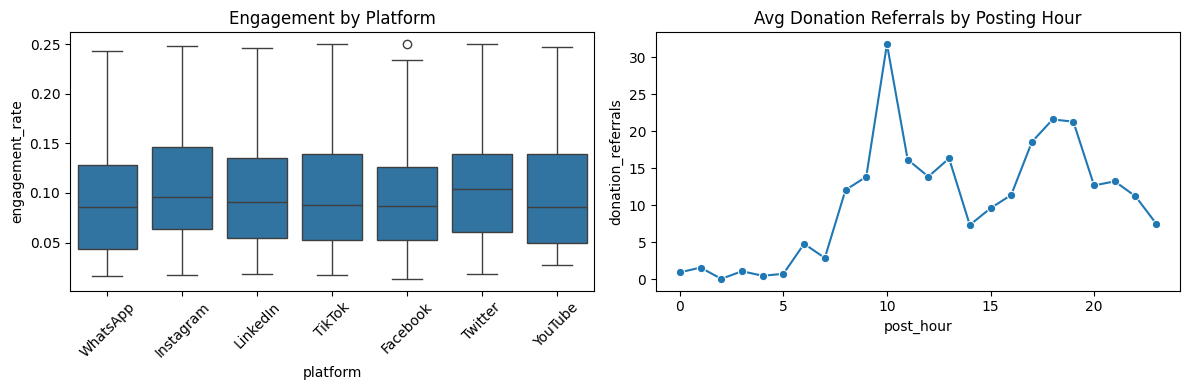

In [4]:
import numpy as np
import subprocess
import sys

try:
    import seaborn as sns
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn', 'matplotlib'])
    import seaborn as sns
    import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='platform', y='engagement_rate', ax=axes[0])
axes[0].set_title('Engagement by Platform')
axes[0].tick_params(axis='x', rotation=45)

hourly = df.groupby('post_hour', as_index=False)['donation_referrals'].mean()
sns.lineplot(data=hourly, x='post_hour', y='donation_referrals', marker='o', ax=axes[1])
axes[1].set_title('Avg Donation Referrals by Posting Hour')
plt.tight_layout()
plt.show()

In [5]:
eng_results, eng_best_model = train_engagement_models(X, y_eng)
print('Predictive engagement results:')
display(eng_results)

Predictive engagement results:


,model,r2,mae
0,random_forest_regressor,0.722846,0.022132
1,linear_regression,0.438727,0.033709


In [6]:
ref_metrics, ref_model, ref_coef = train_referral_models(X, y_ref_bin)
print('Predictive referral metrics:', {k: round(v,4) for k,v in ref_metrics.items()})
print('Explanatory drivers of referral probability (top positive):')
display(ref_coef.head(12))
print('Top negative:')
display(ref_coef.tail(12).sort_values('coefficient'))

Predictive referral metrics: {'roc_auc': 0.8881, 'pr_auc': 0.9288}
Explanatory drivers of referral probability (top positive):


,feature,coefficient,odds_ratio
25,cat__post_type_ImpactStory,2.634259,13.932990
0,num__post_hour,0.990099,2.691502
21,cat__post_type_Campaign,0.923865,2.519007
29,cat__media_type_Reel,0.769099,2.157821
38,cat__content_topic_CampaignLaunch,0.692659,1.999024
47,cat__sentiment_tone_Emotional,0.687924,1.989580
24,cat__post_type_FundraisingAppeal,0.668956,1.952198
13,cat__platform_YouTube,0.666462,1.947335
15,cat__day_of_week_Monday,0.545355,1.725221
46,cat__sentiment_tone_Celebratory,0.518180,1.678969


Top negative:


,feature,coefficient,odds_ratio
23,cat__post_type_EventPromotion,-1.704734,0.181821
22,cat__post_type_EducationalContent,-1.356968,0.257440
50,cat__sentiment_tone_Informative,-1.235390,0.290721
26,cat__post_type_ThankYou,-1.160243,0.313410
9,cat__platform_LinkedIn,-0.765974,0.464881
30,cat__media_type_Text,-0.719711,0.486893
41,cat__content_topic_EventRecap,-0.500401,0.606287
19,cat__day_of_week_Tuesday,-0.466080,0.627457
37,cat__content_topic_AwarenessRaising,-0.416411,0.659409
44,cat__content_topic_Reintegration,-0.276453,0.758469


In [7]:
# Threshold tuning + FP/FN cost table for referral classifier
ref_proba_full = ref_model.predict_proba(X)[:, 1]
thresholds = np.arange(0.1, 0.95, 0.05)
fp_cost = 1.0
fn_cost = 3.0
rows = []
for t in thresholds:
    pred = (ref_proba_full >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_ref_bin, pred, labels=[0, 1]).ravel()
    total_cost = fp_cost * fp + fn_cost * fn
    rows.append({'threshold': round(float(t), 2), 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn), 'total_cost': float(total_cost)})

cost_df = pd.DataFrame(rows).sort_values('total_cost').reset_index(drop=True)
display(cost_df.head(10))
best_t = float(cost_df.loc[0, 'threshold'])
print(f'Selected threshold by cost minimization: {best_t:.2f}')

,threshold,tp,fp,fn,tn,total_cost
0,0.20,516,165,6,125,183.0
1,0.15,517,182,5,108,197.0
2,0.25,505,146,17,144,197.0
3,0.30,497,126,25,164,201.0
4,0.35,485,109,37,181,220.0
5,0.10,520,215,2,75,221.0
6,0.40,476,91,46,199,229.0
7,0.45,468,77,54,213,239.0
8,0.50,454,66,68,224,270.0
9,0.55,441,58,81,232,301.0


Selected threshold by cost minimization: 0.20


## Evaluation In Business Terms
- False positives: extra outreach spend on low-response posts.
- False negatives: missed opportunities for high-value campaigns.
- Use this model to prioritize posting schedules/platform-content combos.

## Operationalization Policy + Monitoring

- Threshold policy: select threshold minimizing FP/FN cost table from this notebook; default fallback 0.45.
- Action bands: high-priority outreach list for top probability decile; medium for A/B testing; low for holdout/control.
- Retraining cadence: monthly retrain or earlier if referral PR-AUC drops >15%.
- Monitoring references:
  - `ml-pipelines/integration/pipeline_registry.yaml`
  - `ml-pipelines/integration/monitoring_spec.md`
  - `ml-pipelines/integration/README.md`

## Causal Caveat
These coefficients are associations from observational data; they do not prove causality.

## Deployment Notes
Expose predictions in the app as a campaign planning widget: input post attributes, output expected engagement and referral likelihood.